# U-Net Training (10-Band + Indices)

Train a pixel-wise U-Net model on `new_dataset` (`*_img.tif` / `*_msk.tif`).

- Input: 16 features (`B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDBI,MNDWI,BSI,DBI,NSI`)
- Target classes: 1..4 (`0` is ignored in loss/metrics)
- Output artifact: `best_unet_10b.pth`

In [13]:
import sys
!{sys.executable} -m pip install -q torch torchvision rasterio scikit-learn matplotlib pandas


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: c:\Users\user\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import random
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 39
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.benchmark = True
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PROJECT_DIR = Path(r'c:/satellite/project')
DATASET_DIR = PROJECT_DIR / 'new_dataset'
OUT_MODEL = PROJECT_DIR / 'best_unet_16b_3.pth'

CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_IDS = [1, 2, 3, 4]
EPS = 1e-6

EPOCHS = 25
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Windows + rasterio in notebook multiprocessing can crash worker processes.
# Keep GPU training enabled, but use safer dataloader worker settings on Windows.
IS_WINDOWS = (os.name == 'nt')
NUM_WORKERS = 0 if IS_WINDOWS else (2 if torch.cuda.is_available() else 0)
PIN_MEMORY = torch.cuda.is_available()
print(f'DataLoader settings -> num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}')
if IS_WINDOWS and NUM_WORKERS == 0:
    print('Using single-process DataLoader for stability on Windows.')

FEATURE_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12','NDVI','NDBI','MNDWI','BSI','DBI','NSI','SWIR_NIR']

Device: cuda
GPU: NVIDIA GeForce RTX 4060
DataLoader settings -> num_workers=0, pin_memory=True
Using single-process DataLoader for stability on Windows.


In [15]:
img_paths = sorted(DATASET_DIR.glob('*_img.tif'))
msk_paths = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in img_paths}
msk_lookup = {sample_id(p): p for p in msk_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=RANDOM_STATE)

print(f'Paired samples: {len(pairs)}')
print(f'Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}')
print(f'Unmatched images: {len(set(img_lookup)-set(msk_lookup))}')
print(f'Unmatched masks: {len(set(msk_lookup)-set(img_lookup))}')

Paired samples: 3126
Train pairs: 2500 | Val pairs: 626
Unmatched images: 0
Unmatched masks: 0


In [ ]:
def normalize_spectral_10(cube: np.ndarray) -> np.ndarray:
    # new_dataset may contain extra channels; use first 10 as B2..B12 contract
    x = cube[:10].astype(np.float32)
    probe = np.nanpercentile(x, 99)
    if probe > 2.0:
        x = np.clip(x / 10000.0, 0.0, 1.0)
    else:
        x = np.clip(x, 0.0, 1.0)
    return x

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    b2 = spectral_norm[0]
    b3 = spectral_norm[1]
    b4 = spectral_norm[2]
    b8 = spectral_norm[6]
    b8a = spectral_norm[7]
    b11 = spectral_norm[8]

    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi = ndbi - ndvi
    swir_nir = b11 / (b8 + EPS)
    swir_nir = np.clip(swir_nir, 0.0, 30.0)
    swir_nir = swir_nir / 30.0
    nsi = (b11 - b8a) / (b11 + b8a + EPS)

    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi, swir_nir], axis=0).astype(np.float32)

def build_unet_features(cube: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10(cube)  # (10, H, W)
    indices = compute_spectral_indices(spectral_norm)  # (7, H, W)
    return np.concatenate([spectral_norm, indices], axis=0).astype(np.float32)  # (17, H, W)

class RasterSegDataset(Dataset):
    def __init__(self, pair_list, augment=False):
        self.pairs = pair_list
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)
        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int64)

        x = build_unet_features(image_cube)
        y = mask

        if self.augment:
            if random.random() < 0.5:
                x = x[:, :, ::-1].copy()
                y = y[:, ::-1].copy()
            if random.random() < 0.5:
                x = x[:, ::-1, :].copy()
                y = y[::-1, :].copy()

        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = RasterSegDataset(train_pairs, augment=True)
val_ds = RasterSegDataset(val_pairs, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

x0, y0 = train_ds[0]
print('Sample tensor:', x0.shape, y0.shape, 'mask classes:', torch.unique(y0).tolist())

Sample tensor: torch.Size([17, 256, 256]) torch.Size([256, 256]) mask classes: [2]


In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=17, n_classes=5, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, 2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, 2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, 2)
        self.dec1 = ConvBlock(base*2, base)

        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.outc(d1)

model = UNetSmall(in_ch=len(FEATURE_NAMES), n_classes=5, base=32).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

sum(p.numel() for p in model.parameters())

1932581

In [18]:
def iou_per_class_np(y_true, y_pred, class_ids):
    out = {}
    for c in class_ids:
        inter = np.sum((y_true == c) & (y_pred == c))
        union = np.sum((y_true == c) | (y_pred == c))
        out[c] = inter / union if union > 0 else np.nan
    return out

def run_epoch(loader, training=True):
    model.train(training)
    losses = []
    all_true = []
    all_pred = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()

        losses.append(loss.item())

        pred = torch.argmax(logits, dim=1)
        y_true_np = yb.detach().cpu().numpy()
        y_pred_np = pred.detach().cpu().numpy()

        valid = y_true_np != 0
        if np.any(valid):
            all_true.append(y_true_np[valid])
            all_pred.append(y_pred_np[valid])

    if len(all_true) == 0:
        return float(np.mean(losses)), np.nan, np.nan, {c: np.nan for c in CLASS_IDS}

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    ious = iou_per_class_np(y_true, y_pred, CLASS_IDS)
    miou = float(np.nanmean([ious[c] for c in CLASS_IDS]))
    acc = float(np.mean(y_true == y_pred))
    return float(np.mean(losses)), acc, miou, ious

In [19]:
history = []
best_miou = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_miou, tr_ious = run_epoch(train_loader, training=True)
    va_loss, va_acc, va_miou, va_ious = run_epoch(val_loader, training=False)

    scheduler.step(va_miou if np.isfinite(va_miou) else 0.0)

    row = {
        'epoch': epoch,
        'train_loss': tr_loss,
        'train_acc': tr_acc,
        'train_miou': tr_miou,
        'val_loss': va_loss,
        'val_acc': va_acc,
        'val_miou': va_miou,
        'acc_gap_train_minus_val': (tr_acc - va_acc) if (np.isfinite(tr_acc) and np.isfinite(va_acc)) else np.nan,
        'lr': optimizer.param_groups[0]['lr'],
    }
    for c in CLASS_IDS:
        row[f'val_iou_{CLASS_NAMES[c]}'] = va_ious[c]
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} tr_mIoU={tr_miou:.4f} | "
        f"va_loss={va_loss:.4f} va_acc={va_acc:.4f} va_mIoU={va_miou:.4f} | "
        f"acc_gap={row['acc_gap_train_minus_val']:.4f}"
    )

    if np.isfinite(va_miou) and va_miou > best_miou:
        best_miou = va_miou
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

hist_df = pd.DataFrame(history)
hist_df.tail()

Epoch 01/5 | tr_loss=0.4210 tr_acc=0.9107 tr_mIoU=0.8317 | va_loss=0.2375 va_acc=0.9504 va_mIoU=0.9024 | acc_gap=-0.0396
Epoch 02/5 | tr_loss=0.2381 tr_acc=0.9308 tr_mIoU=0.8670 | va_loss=0.2447 va_acc=0.9178 va_mIoU=0.8423 | acc_gap=0.0130
Epoch 03/5 | tr_loss=0.1740 tr_acc=0.9483 tr_mIoU=0.8959 | va_loss=0.1778 va_acc=0.9435 va_mIoU=0.8931 | acc_gap=0.0048
Epoch 04/5 | tr_loss=0.1417 tr_acc=0.9552 tr_mIoU=0.9086 | va_loss=0.0867 va_acc=0.9722 va_mIoU=0.9426 | acc_gap=-0.0170
Epoch 05/5 | tr_loss=0.1405 tr_acc=0.9584 tr_mIoU=0.9144 | va_loss=0.1093 va_acc=0.9634 va_mIoU=0.9263 | acc_gap=-0.0049


,epoch,train_loss,train_acc,train_miou,val_loss,val_acc,val_miou,acc_gap_train_minus_val,lr,val_iou_Greenery,val_iou_Sand,val_iou_Water,val_iou_Cement
0,1,0.420995,0.910713,0.831733,0.237473,0.950350,0.902426,-0.039637,0.001,0.861294,0.937507,0.977960,0.832943
1,2,0.238077,0.930823,0.866969,0.244701,0.917850,0.842345,0.012974,0.001,0.827255,0.888521,0.988603,0.665001
2,3,0.174029,0.948305,0.895900,0.177799,0.943494,0.893089,0.004811,0.001,0.859649,0.924461,0.985889,0.802359
3,4,0.141746,0.955200,0.908629,0.086691,0.972215,0.942567,-0.017014,0.001,0.913035,0.969859,0.987984,0.899389
4,5,0.140523,0.958415,0.914406,0.109268,0.963352,0.926340,-0.004937,0.001,0.905029,0.949876,0.990109,0.860347


In [20]:
if best_state is not None:
    model.load_state_dict(best_state)

payload = {
    'model_state_dict': model.state_dict(),
    'model_type': 'unet_small',
    'in_channels': len(FEATURE_NAMES),
    'num_classes': 5,
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'best_val_miou': float(best_miou),
    'config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'random_state': RANDOM_STATE
    }
}

torch.save(payload, OUT_MODEL)
print('Saved:', OUT_MODEL)
print('Best val mIoU:', round(float(best_miou), 4))

Saved: c:\satellite\project\best_unet_16b_2.pth
Best val mIoU: 0.9426


              precision    recall  f1-score   support

    Greenery       0.96      0.95      0.95   7922051
        Sand       0.99      0.98      0.98  14503233
       Water       1.00      0.99      0.99   9169937
      Cement       0.93      0.96      0.95   9353980

    accuracy                           0.97  40949201
   macro avg       0.97      0.97      0.97  40949201
weighted avg       0.97      0.97      0.97  40949201



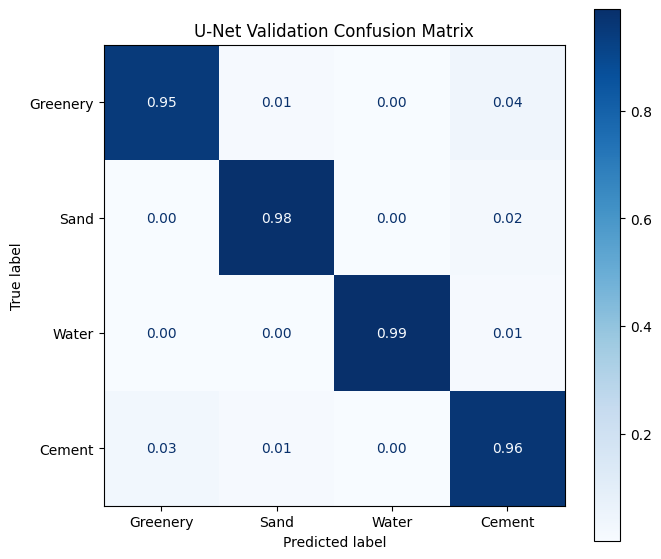

In [21]:
# Final validation report (excluding class 0)
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        y_true = yb.numpy()
        valid = y_true != 0
        if np.any(valid):
            all_true.append(y_true[valid])
            all_pred.append(pred[valid])

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]).plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title('U-Net Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## Test-data feature visualization and feature ranges

Visualize test masks alongside extracted feature maps, and inspect feature value ranges per sample and across all test samples.

In [22]:
TEST_DATA_DIR = PROJECT_DIR / 'data/test_data'

INDEX_NAMES = ['NDVI', 'NDBI', 'MNDWI', 'BSI', 'DBI', 'NSI']
TEST_FEATURE_NAMES = FEATURE_NAMES + INDEX_NAMES

IDX_B2, IDX_B3, IDX_B4 = 1, 2, 3
IDX_B5, IDX_B6, IDX_B7 = 4, 5, 6
IDX_B8, IDX_B8A, IDX_B11, IDX_B12 = 7, 8, 10, 11


def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Spectral.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    name = name.replace('_Mask.tif', '')
    return name


def normalize_spectral_10_from_test(cube12: np.ndarray) -> np.ndarray:
    spectral_10 = np.stack([
        cube12[IDX_B2], cube12[IDX_B3], cube12[IDX_B4], cube12[IDX_B5], cube12[IDX_B6],
        cube12[IDX_B7], cube12[IDX_B8], cube12[IDX_B8A], cube12[IDX_B11], cube12[IDX_B12]
    ], axis=0).astype(np.float32)

    probe = np.nanpercentile(spectral_10, 99)
    if probe > 2.0:
        spectral_10 = np.clip(spectral_10 / 10000.0, 0.0, 1.0)
    else:
        spectral_10 = np.clip(spectral_10, 0.0, 1.0)
    return spectral_10


def build_unet_features_from_test(cube12: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10_from_test(cube12)
    indices = compute_spectral_indices(spectral_norm)
    return np.concatenate([spectral_norm, indices], axis=0).astype(np.float32)


def make_test_rgb(cube12: np.ndarray) -> np.ndarray:
    rgb = np.stack([
        cube12[IDX_B4].astype(np.float32),
        cube12[IDX_B3].astype(np.float32),
        cube12[IDX_B2].astype(np.float32),
    ], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0.0, 1.0)


spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral*.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask*.tif'))

spectral_lookup = {pair_id(p): p for p in spectral_files}
mask_lookup = {pair_id(p): p for p in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))

test_pairs = [
    {'name': sid, 'spectral_path': spectral_lookup[sid], 'mask_path': mask_lookup[sid]}
    for sid in common_ids
]

print(f'Test data directory: {TEST_DATA_DIR}')
print(f'Paired test samples: {len(test_pairs)}')
print(f'Unmatched spectral files: {len(set(spectral_lookup) - set(mask_lookup))}')
print(f'Unmatched mask files: {len(set(mask_lookup) - set(spectral_lookup))}')

Test data directory: c:\satellite\project\data\test_data
Paired test samples: 6
Unmatched spectral files: 0
Unmatched mask files: 0


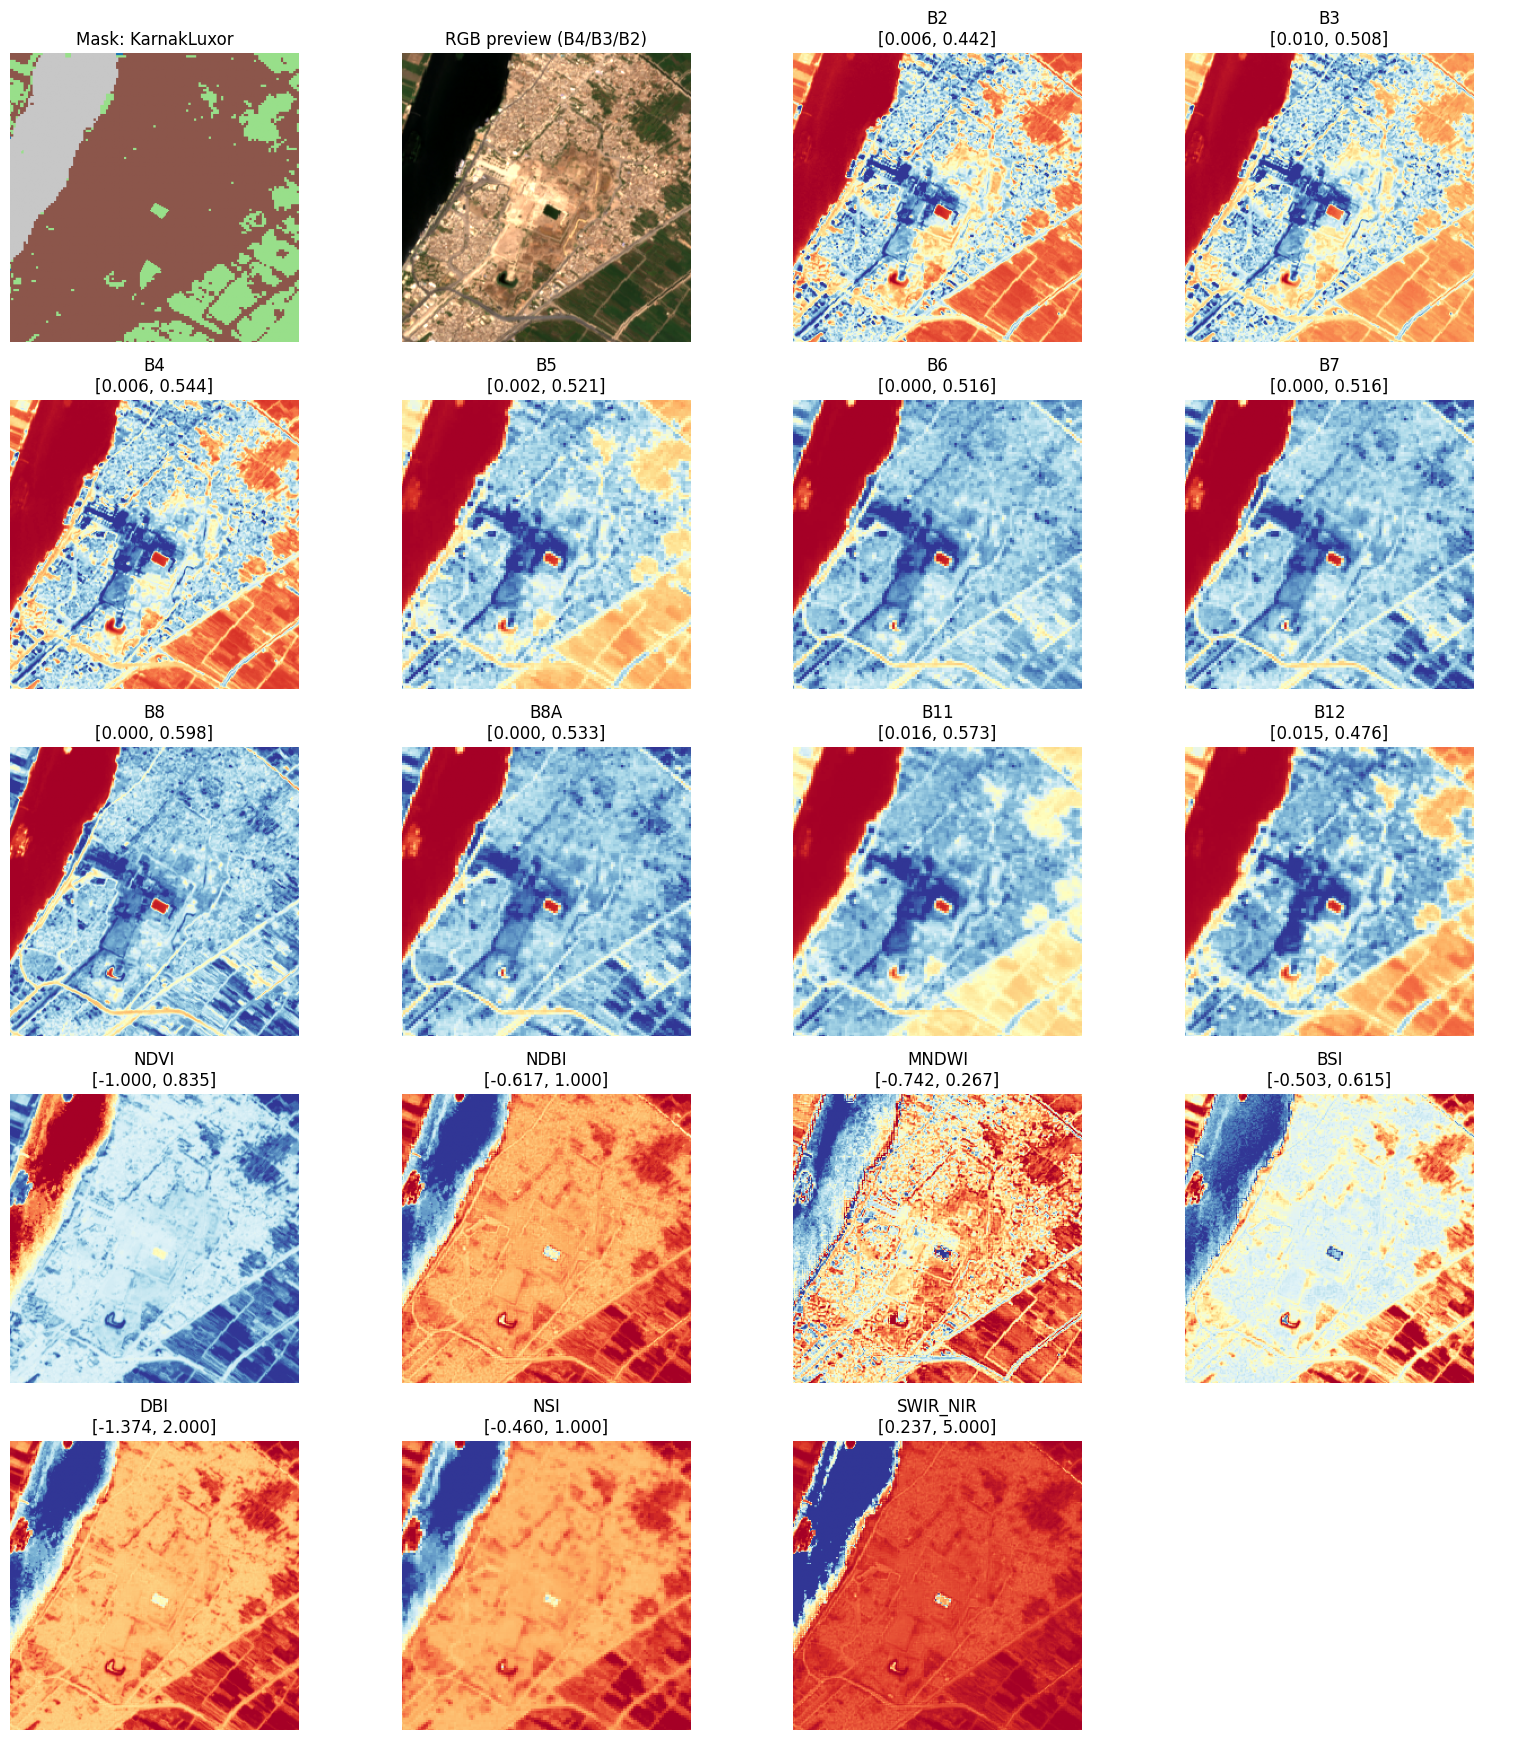

Sample: KarnakLuxor | feature tensor shape: (17, 256, 256)


,feature,min,max,mean,std
0,B2,0.005850,0.442200,0.109537,0.062194
1,B3,0.010250,0.507800,0.147446,0.075452
2,B4,0.005550,0.543800,0.176518,0.102361
3,B5,0.002100,0.521400,0.208096,0.102944
4,B6,0.000000,0.516150,0.254025,0.108972
5,B7,0.000000,0.516450,0.272123,0.117187
6,B8,0.000000,0.598200,0.285660,0.125041
7,B8A,0.000000,0.532600,0.283999,0.121256
8,B11,0.016000,0.573100,0.272692,0.120202
9,B12,0.014600,0.475900,0.229365,0.114274


Global feature ranges across all paired test samples:


,feature,global_min,global_max
0,B2,0.000000,0.782800
1,B3,0.010000,0.812800
2,B4,0.000000,0.814000
3,B5,0.002100,0.813050
4,B6,0.000000,0.785600
5,B7,0.000000,0.785350
6,B8,0.000000,0.836800
7,B8A,0.000000,0.770100
8,B11,0.016000,0.821800
9,B12,0.014600,0.732700


In [23]:
def visualize_test_sample_features(sample_name: str = None, max_features: int = 16):
    if not test_pairs:
        raise ValueError(f'No paired test samples found in {TEST_DATA_DIR}')

    if sample_name is None:
        sample_item = test_pairs[0]
    else:
        selected = [x for x in test_pairs if x['name'] == sample_name]
        if not selected:
            raise ValueError(f'Sample {sample_name} not found. Available: {[x["name"] for x in test_pairs]}')
        sample_item = selected[0]

    with rasterio.open(sample_item['spectral_path']) as src:
        cube12 = src.read().astype(np.float32)
    with rasterio.open(sample_item['mask_path']) as src:
        mask = src.read(1).astype(np.int32)

    feats = build_unet_features_from_test(cube12)
    feat_names = TEST_FEATURE_NAMES[:feats.shape[0]]

    n_feat_show = min(max_features, feats.shape[0])
    n_panels = 2 + n_feat_show  # mask + rgb + feature maps
    n_cols = 4
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(mask, cmap='tab20', vmin=0, vmax=max(CLASS_IDS))
    axes[0].set_title(f"Mask: {sample_item['name']}")
    axes[0].axis('off')

    axes[1].imshow(make_test_rgb(cube12))
    axes[1].set_title('RGB preview (B4/B3/B2)')
    axes[1].axis('off')

    for i in range(n_feat_show):
        ch = feats[i]
        ch_min = float(np.nanmin(ch))
        ch_max = float(np.nanmax(ch))
        p2, p98 = np.nanpercentile(ch, [2, 98])
        ax = axes[2 + i]
        ax.imshow(ch, cmap='RdYlBu', vmin=p2, vmax=p98)
        ax.set_title(f"{feat_names[i]}\n[{ch_min:.3f}, {ch_max:.3f}]")
        ax.axis('off')

    for j in range(n_panels, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    ranges_df = pd.DataFrame({
        'feature': feat_names,
        'min': [float(np.nanmin(feats[i])) for i in range(feats.shape[0])],
        'max': [float(np.nanmax(feats[i])) for i in range(feats.shape[0])],
        'mean': [float(np.nanmean(feats[i])) for i in range(feats.shape[0])],
        'std': [float(np.nanstd(feats[i])) for i in range(feats.shape[0])],
    })

    print(f"Sample: {sample_item['name']} | feature tensor shape: {feats.shape}")
    display(ranges_df)
    return ranges_df


def summarize_feature_ranges_all_test():
    if not test_pairs:
        raise ValueError(f'No paired test samples found in {TEST_DATA_DIR}')

    per_sample_rows = []
    global_min = None
    global_max = None

    for item in test_pairs:
        with rasterio.open(item['spectral_path']) as src:
            cube12 = src.read().astype(np.float32)

        feats = build_unet_features_from_test(cube12)
        feat_min = np.nanmin(feats, axis=(1, 2))
        feat_max = np.nanmax(feats, axis=(1, 2))

        if global_min is None:
            global_min = feat_min.copy()
            global_max = feat_max.copy()
        else:
            global_min = np.minimum(global_min, feat_min)
            global_max = np.maximum(global_max, feat_max)

        for i, name in enumerate(TEST_FEATURE_NAMES[:feats.shape[0]]):
            per_sample_rows.append({
                'sample': item['name'],
                'feature': name,
                'min': float(feat_min[i]),
                'max': float(feat_max[i]),
            })

    per_sample_df = pd.DataFrame(per_sample_rows)
    global_df = pd.DataFrame({
        'feature': TEST_FEATURE_NAMES[:len(global_min)],
        'global_min': global_min.astype(np.float32),
        'global_max': global_max.astype(np.float32),
    })

    print('Global feature ranges across all paired test samples:')
    display(global_df)
    return per_sample_df, global_df


_ = visualize_test_sample_features(sample_name='KarnakLuxor', max_features=17)
per_sample_feature_ranges_df, global_feature_ranges_df = summarize_feature_ranges_all_test()